<a href="https://colab.research.google.com/github/vucse241fa04b96-lang/CodeAlpha-Tasks/blob/main/Task4_Sentiment_Analysis/Task4_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 CodeAlpha Internship – Task 4

## Data Visualization

#Sentiment Analysis

## Introduction

Sentiment Analysis is a Natural Language Processing (NLP) technique used to identify the emotional tone of text.

In this task, customer reviews are analyzed and classified into:
- Positive
- Negative
- Neutral

The analysis helps understand customer opinions, satisfaction levels, and sentiment patterns.

In [ ]:
# Install required libraries
!pip install nltk textblob wordcloud -q

# Import Libraries

The following Python libraries are used:
- Pandas for data handling
- NumPy for numerical operations
- Matplotlib and Seaborn for visualization
- NLTK for Natural Language Processing
- TextBlob for sentiment analysis
- WordCloud for displaying frequently used words

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from textblob import TextBlob
from wordcloud import WordCloud

print("All libraries imported successfully!")

All libraries imported successfully!


# Download NLTK Resources

NLTK resources are downloaded for text processing.

In [ ]:
nltk.download("punkt")
nltk.download("stopwords")

print("NLTK resources downloaded successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK resources downloaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Create Customer Review Dataset

For this task, a small customer review dataset is created.

Each review contains:
- Review ID
- Customer Review
- Product Category

The reviews represent positive, negative, and neutral customer opinions.

In [ ]:
data = {
    "Review_ID": range(1, 21),
    "Review": [
        "This product is excellent and I really love it.",
        "Amazing quality and very useful product.",
        "I am extremely happy with this purchase.",
        "The product works perfectly and I recommend it.",
        "Fantastic product with great quality.",
        "Very good product and worth the money.",
        "I am satisfied with the product.",
        "The product is okay and works as expected.",
        "It is an average product for the price.",
        "The product is normal and nothing special.",
        "The quality is acceptable.",
        "The product arrived on time.",
        "I do not like this product at all.",
        "Very poor quality and disappointing.",
        "The product stopped working after a few days.",
        "Terrible experience and waste of money.",
        "I am unhappy with this purchase.",
        "The product quality is bad.",
        "Very disappointing product.",
        "I would not recommend this product."
    ],
    "Category": [
        "Electronics", "Electronics", "Fashion", "Electronics",
        "Home", "Fashion", "Home", "Electronics",
        "Fashion", "Home", "Electronics", "Home",
        "Electronics", "Fashion", "Electronics", "Home",
        "Fashion", "Electronics", "Home", "Fashion"
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
df.head()

Dataset created successfully!


,Review_ID,Review,Category
0,1,This product is excellent and I really love it.,Electronics
1,2,Amazing quality and very useful product.,Electronics
2,3,I am extremely happy with this purchase.,Fashion
3,4,The product works perfectly and I recommend it.,Electronics
4,5,Fantastic product with great quality.,Home


# View Dataset

The first few records of the dataset are displayed to understand its structure.

In [ ]:
print(df.head())

   Review_ID                                           Review     Category
0          1  This product is excellent and I really love it.  Electronics
1          2         Amazing quality and very useful product.  Electronics
2          3         I am extremely happy with this purchase.      Fashion
3          4  The product works perfectly and I recommend it.  Electronics
4          5            Fantastic product with great quality.         Home


# Dataset Information

The dataset structure, number of records, and data types are checked before performing sentiment analysis.

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Number of rows: 20
Number of columns: 3

Column Names:
['Review_ID', 'Review', 'Category']

Data Types:
Review_ID     int64
Review       object
Category     object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review_ID  20 non-null     int64 
 1   Review     20 non-null     object
 2   Category   20 non-null     object
dtypes: int64(1), object(2)
memory usage: 612.0+ bytes


# Check Missing Values

Missing values can affect the accuracy of sentiment analysis, so they are checked before processing.

In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Review_ID    0
Review       0
Category     0
dtype: int64


# Check Duplicate Reviews

Duplicate reviews are identified to maintain data quality.

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


# Remove Duplicate Reviews

Duplicate records are removed if they are present.

In [ ]:
df = df.drop_duplicates()

print("Duplicate records removed!")
print("Current dataset size:", df.shape)

Duplicate records removed!
Current dataset size: (20, 3)


# Text Cleaning

Text cleaning removes unnecessary characters and converts the text into a consistent format.

The following steps are performed:
- Convert text to lowercase
- Remove URLs
- Remove special characters
- Remove extra spaces

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["Cleaned_Review"] = df["Review"].apply(clean_text)

df[["Review", "Cleaned_Review"]].head()

,Review,Cleaned_Review
0,This product is excellent and I really love it.,this product is excellent and i really love it
1,Amazing quality and very useful product.,amazing quality and very useful product
2,I am extremely happy with this purchase.,i am extremely happy with this purchase
3,The product works perfectly and I recommend it.,the product works perfectly and i recommend it
4,Fantastic product with great quality.,fantastic product with great quality


# Remove Stopwords

Common words such as "the", "is", "and", and "a" are removed because they generally provide less information for word-frequency analysis.

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["Processed_Review"] = df["Cleaned_Review"].apply(remove_stopwords)

df[["Cleaned_Review", "Processed_Review"]].head()

,Cleaned_Review,Processed_Review
0,this product is excellent and i really love it,product excellent really love
1,amazing quality and very useful product,amazing quality useful product
2,i am extremely happy with this purchase,extremely happy purchase
3,the product works perfectly and i recommend it,product works perfectly recommend
4,fantastic product with great quality,fantastic product great quality


# Calculate Sentiment Polarity

TextBlob is used to calculate sentiment polarity.

Polarity ranges from:
- -1 → Very Negative
- 0 → Neutral
- +1 → Very Positive

In [ ]:
df["Polarity"] = df["Cleaned_Review"].apply(
    lambda text: TextBlob(text).sentiment.polarity
)

df[["Review", "Polarity"]].head()

,Review,Polarity
0,This product is excellent and I really love it.,0.750
1,Amazing quality and very useful product.,0.495
2,I am extremely happy with this purchase.,0.800
3,The product works perfectly and I recommend it.,1.000
4,Fantastic product with great quality.,0.600


# Classify Sentiment

Reviews are classified into Positive, Negative, or Neutral based on their polarity score.

Rules:
- Polarity > 0 → Positive
- Polarity < 0 → Negative
- Polarity = 0 → Neutral

In [ ]:
def classify_sentiment(polarity):
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Polarity"].apply(classify_sentiment)

df[["Review", "Polarity", "Sentiment"]]

,Review,Polarity,Sentiment
0,This product is excellent and I really love it.,0.750000,Positive
1,Amazing quality and very useful product.,0.495000,Positive
2,I am extremely happy with this purchase.,0.800000,Positive
3,The product works perfectly and I recommend it.,1.000000,Positive
4,Fantastic product with great quality.,0.600000,Positive
5,Very good product and worth the money.,0.605000,Positive
6,I am satisfied with the product.,0.500000,Positive
7,The product is okay and works as expected.,0.200000,Positive
8,It is an average product for the price.,-0.150000,Negative
9,The product is normal and nothing special.,0.253571,Positive


# Sentiment Analysis Results

The complete dataset is displayed with the sentiment score and sentiment category.

In [ ]:
print(df[["Review", "Polarity", "Sentiment"]].to_string(index=False))

                                         Review  Polarity Sentiment
This product is excellent and I really love it.  0.750000  Positive
       Amazing quality and very useful product.  0.495000  Positive
       I am extremely happy with this purchase.  0.800000  Positive
The product works perfectly and I recommend it.  1.000000  Positive
          Fantastic product with great quality.  0.600000  Positive
         Very good product and worth the money.  0.605000  Positive
               I am satisfied with the product.  0.500000  Positive
     The product is okay and works as expected.  0.200000  Positive
        It is an average product for the price. -0.150000  Negative
     The product is normal and nothing special.  0.253571  Positive
                     The quality is acceptable.  0.000000   Neutral
                   The product arrived on time.  0.000000   Neutral
             I do not like this product at all.  0.000000   Neutral
           Very poor quality and disappointing. 

# Count of Sentiments

The number of Positive, Negative, and Neutral reviews is calculated.

In [ ]:
sentiment_counts = df["Sentiment"].value_counts()

print("Sentiment Counts:")
print(sentiment_counts)

Sentiment Counts:
Sentiment
Positive    9
Negative    7
Neutral     4
Name: count, dtype: int64


# Sentiment Distribution

A bar chart is created to visualize the distribution of positive, negative, and neutral reviews.

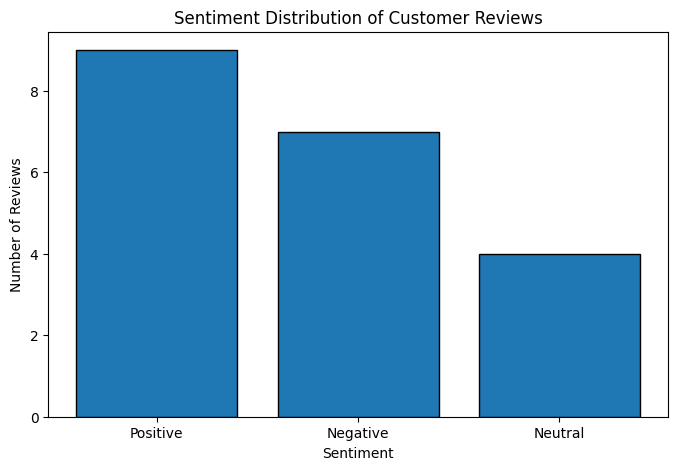

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    edgecolor="black"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution of Customer Reviews")

plt.show()

# Sentiment Percentage

The percentage of each sentiment category is calculated to understand the overall customer opinion.

In [ ]:
sentiment_percentage = (
    df["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Sentiment Percentage:")
print(sentiment_percentage)

Sentiment Percentage:
Sentiment
Positive    45.0
Negative    35.0
Neutral     20.0
Name: proportion, dtype: float64


# Sentiment Percentage Visualization

A pie chart is used to show the percentage distribution of customer sentiments.

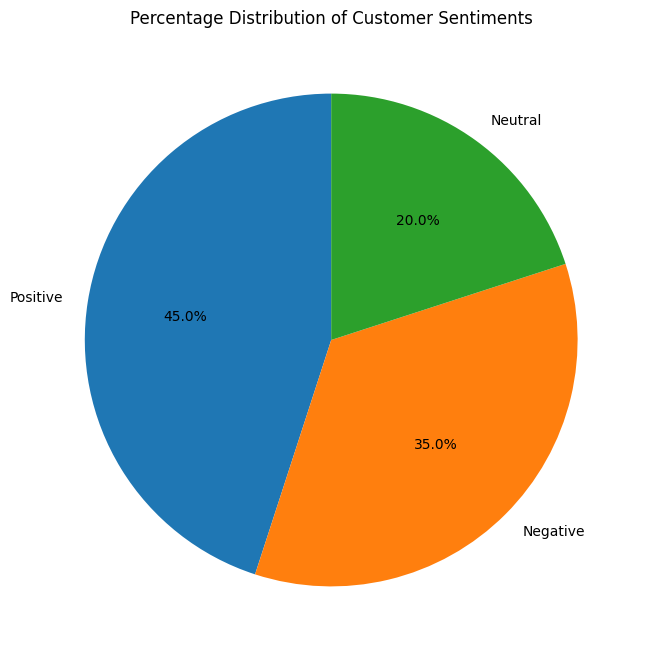

In [ ]:
plt.figure(figsize=(8, 8))

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Customer Sentiments")

plt.show()

# Sentiment by Product Category

Sentiment patterns are analyzed for different product categories.

In [ ]:
category_sentiment = pd.crosstab(
    df["Category"],
    df["Sentiment"]
)

print(category_sentiment)

Sentiment    Negative  Neutral  Positive
Category                                
Electronics         2        2         4
Fashion             3        1         2
Home                2        1         3


# Sentiment by Category Visualization

A grouped bar chart is used to compare customer sentiment across product categories.

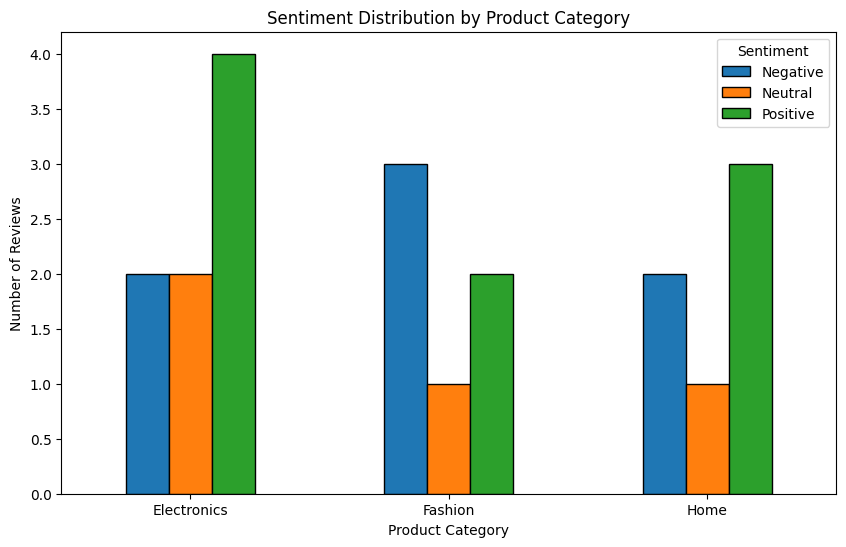

In [ ]:
category_sentiment.plot(
    kind="bar",
    figsize=(10, 6),
    edgecolor="black"
)

plt.xlabel("Product Category")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution by Product Category")
plt.xticks(rotation=0)

plt.show()

# Average Sentiment Polarity by Category

The average polarity score is calculated for each product category.

A higher positive value indicates more positive customer sentiment.
A negative value indicates more negative customer sentiment.

In [ ]:
average_polarity = (
    df.groupby("Category")["Polarity"]
    .mean()
    .round(3)
)

print("Average Sentiment Polarity by Category:")
print(average_polarity)

Average Sentiment Polarity by Category:
Category
Electronics    0.193
Fashion        0.016
Home          -0.004
Name: Polarity, dtype: float64


# Average Polarity Visualization

The average sentiment polarity for each category is visualized using a bar chart.

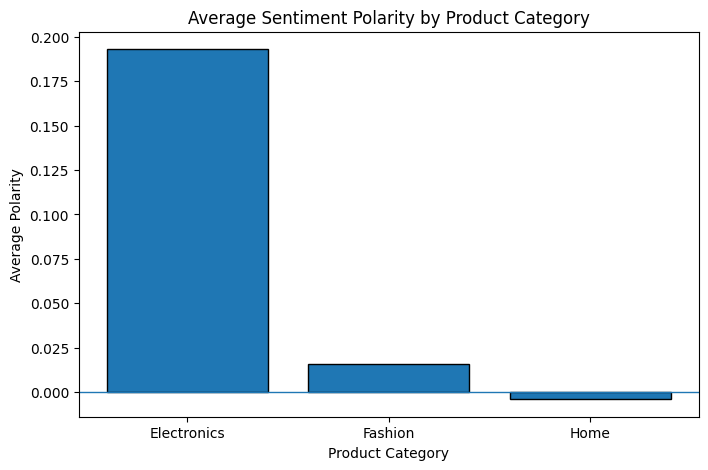

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    average_polarity.index,
    average_polarity.values,
    edgecolor="black"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Product Category")
plt.ylabel("Average Polarity")
plt.title("Average Sentiment Polarity by Product Category")

plt.show()

# Identify Positive Reviews

Positive reviews are filtered to understand what customers liked about the products.

In [ ]:
positive_reviews = df[df["Sentiment"] == "Positive"]

print("Positive Reviews:")
print(positive_reviews[["Review", "Category", "Polarity"]].to_string(index=False))

Positive Reviews:
                                         Review    Category  Polarity
This product is excellent and I really love it. Electronics  0.750000
       Amazing quality and very useful product. Electronics  0.495000
       I am extremely happy with this purchase.     Fashion  0.800000
The product works perfectly and I recommend it. Electronics  1.000000
          Fantastic product with great quality.        Home  0.600000
         Very good product and worth the money.     Fashion  0.605000
               I am satisfied with the product.        Home  0.500000
     The product is okay and works as expected. Electronics  0.200000
     The product is normal and nothing special.        Home  0.253571


# Identify Negative Reviews

Negative reviews are filtered to identify areas where customers were dissatisfied.

In [ ]:
negative_reviews = df[df["Sentiment"] == "Negative"]

print("Negative Reviews:")
print(negative_reviews[["Review", "Category", "Polarity"]].to_string(index=False))

Negative Reviews:
                                       Review    Category  Polarity
      It is an average product for the price.     Fashion     -0.15
         Very poor quality and disappointing.     Fashion     -0.56
The product stopped working after a few days. Electronics     -0.20
      Terrible experience and waste of money.        Home     -0.60
             I am unhappy with this purchase.     Fashion     -0.60
                  The product quality is bad. Electronics     -0.70
                  Very disappointing product.        Home     -0.78


# Identify Neutral Reviews

Neutral reviews are displayed separately to understand reviews with little or no emotional polarity.

In [ ]:
neutral_reviews = df[df["Sentiment"] == "Neutral"]

print("Neutral Reviews:")
print(neutral_reviews[["Review", "Category", "Polarity"]].to_string(index=False))

Neutral Reviews:
                             Review    Category  Polarity
         The quality is acceptable. Electronics       0.0
       The product arrived on time.        Home       0.0
 I do not like this product at all. Electronics       0.0
I would not recommend this product.     Fashion       0.0


# Word Frequency Analysis

Frequently occurring words are identified from the processed reviews.

In [ ]:
from collections import Counter

all_words = " ".join(df["Processed_Review"]).split()

word_counts = Counter(all_words)

common_words = word_counts.most_common(15)

print("Most Common Words:")
for word, count in common_words:
    print(word, ":", count)

Most Common Words:
product : 15
quality : 5
purchase : 2
works : 2
recommend : 2
money : 2
disappointing : 2
excellent : 1
really : 1
love : 1
amazing : 1
useful : 1
extremely : 1
happy : 1
perfectly : 1


# Word Frequency Visualization

The most frequently used words are visualized using a bar chart.

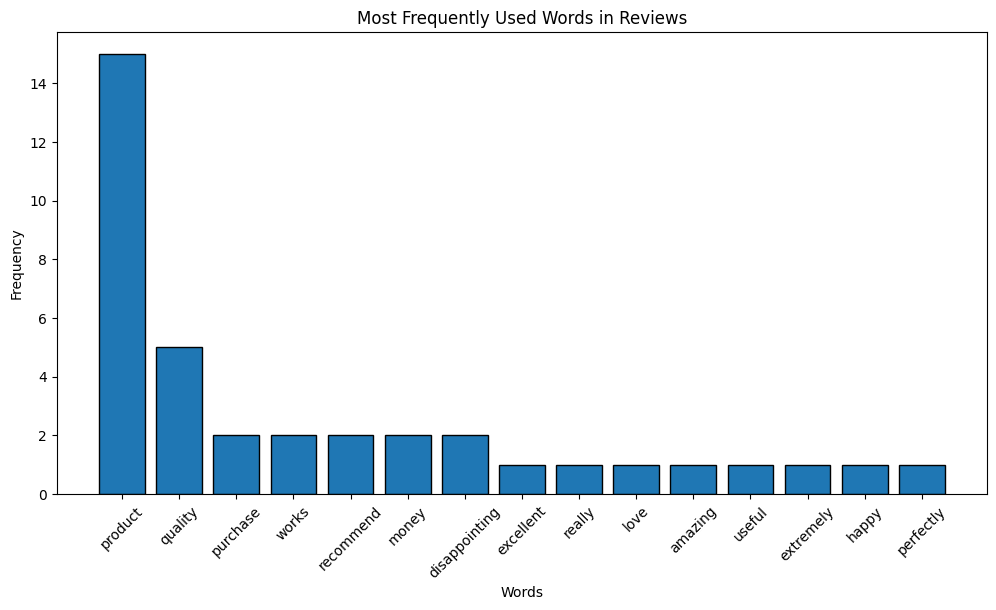

In [ ]:
words = [item[0] for item in common_words]
counts = [item[1] for item in common_words]

plt.figure(figsize=(12, 6))

plt.bar(words, counts, edgecolor="black")

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Most Frequently Used Words in Reviews")

plt.xticks(rotation=45)

plt.show()

# Word Cloud

A word cloud provides a visual representation of frequently used words in customer reviews.

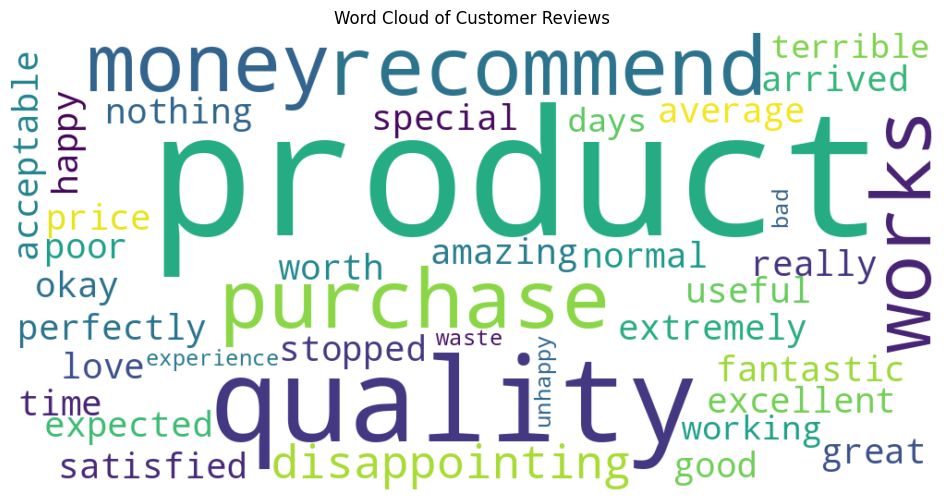

In [ ]:
all_text = " ".join(df["Processed_Review"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")
plt.title("Word Cloud of Customer Reviews")

plt.show()

# Positive and Negative Word Analysis

The most common words in positive and negative reviews are analyzed separately.

In [ ]:
positive_text = " ".join(
    df[df["Sentiment"] == "Positive"]["Processed_Review"]
)

negative_text = " ".join(
    df[df["Sentiment"] == "Negative"]["Processed_Review"]
)

positive_words = Counter(positive_text.split()).most_common(10)
negative_words = Counter(negative_text.split()).most_common(10)

print("Common Words in Positive Reviews:")
print(positive_words)

print("\nCommon Words in Negative Reviews:")
print(negative_words)

Common Words in Positive Reviews:
[('product', 8), ('quality', 2), ('works', 2), ('excellent', 1), ('really', 1), ('love', 1), ('amazing', 1), ('useful', 1), ('extremely', 1), ('happy', 1)]

Common Words in Negative Reviews:
[('product', 4), ('quality', 2), ('disappointing', 2), ('average', 1), ('price', 1), ('poor', 1), ('stopped', 1), ('working', 1), ('days', 1), ('terrible', 1)]


# Emotion Detection

Specific emotional words are identified using a simple emotion lexicon.

The emotions considered are:
- Happy
- Angry
- Sad
- Love
- Disappointed
- Excited

In [ ]:
emotion_lexicon = {
    "Happy": ["happy", "satisfied", "good", "excellent", "amazing", "great"],
    "Angry": ["angry", "terrible", "bad", "poor"],
    "Sad": ["sad", "unhappy", "disappointing", "disappointed"],
    "Love": ["love", "fantastic"],
    "Excited": ["amazing", "excellent", "fantastic"],
}

def detect_emotion(text):
    detected_emotions = []

    words = text.lower().split()

    for emotion, emotion_words in emotion_lexicon.items():
        for word in emotion_words:
            if word in words:
                detected_emotions.append(emotion)
                break

    if len(detected_emotions) == 0:
        return "Neutral"

    return ", ".join(detected_emotions)

df["Emotion"] = df["Cleaned_Review"].apply(detect_emotion)

df[["Review", "Sentiment", "Emotion"]]

,Review,Sentiment,Emotion
0,This product is excellent and I really love it.,Positive,"Happy, Love, Excited"
1,Amazing quality and very useful product.,Positive,"Happy, Excited"
2,I am extremely happy with this purchase.,Positive,Happy
3,The product works perfectly and I recommend it.,Positive,Neutral
4,Fantastic product with great quality.,Positive,"Happy, Love, Excited"
5,Very good product and worth the money.,Positive,Happy
6,I am satisfied with the product.,Positive,Happy
7,The product is okay and works as expected.,Positive,Neutral
8,It is an average product for the price.,Negative,Neutral
9,The product is normal and nothing special.,Positive,Neutral


# Emotion Distribution

The frequency of detected emotions is calculated.

In [ ]:
emotion_counts = df["Emotion"].value_counts()

print("Emotion Distribution:")
print(emotion_counts)

Emotion Distribution:
Emotion
Neutral                 9
Happy                   3
Happy, Love, Excited    2
Sad                     2
Angry                   2
Happy, Excited          1
Angry, Sad              1
Name: count, dtype: int64


# Emotion Visualization

A bar chart is created to visualize the detected emotions in customer reviews.

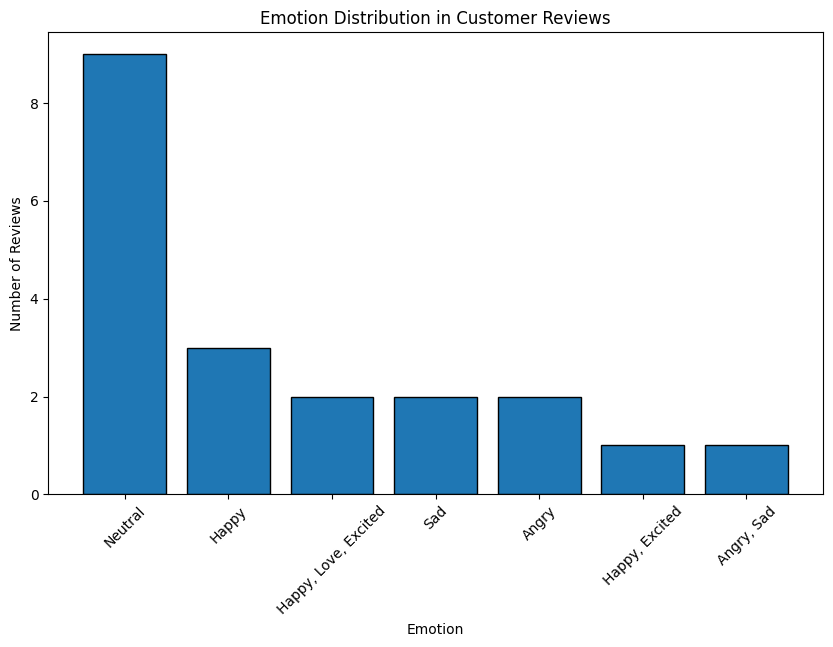

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    emotion_counts.index,
    emotion_counts.values,
    edgecolor="black"
)

plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")
plt.title("Emotion Distribution in Customer Reviews")

plt.xticks(rotation=45)

plt.show()

# Sentiment vs Polarity

The relationship between sentiment categories and polarity scores is visualized using a boxplot.

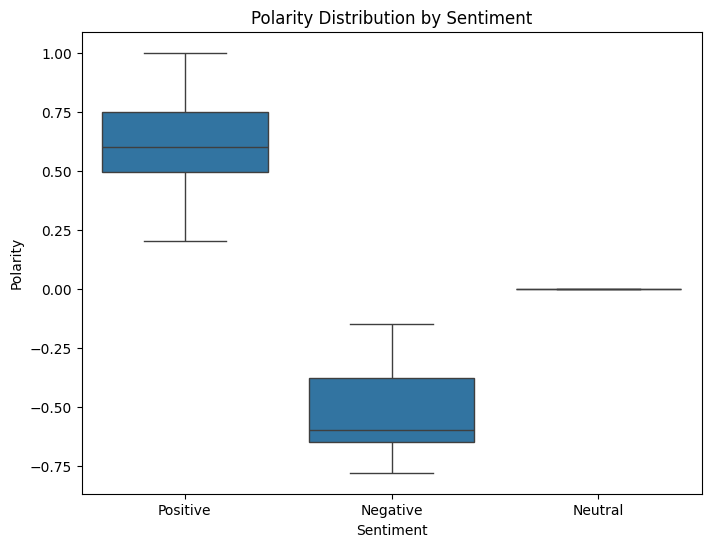

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="Sentiment",
    y="Polarity",
    data=df
)

plt.xlabel("Sentiment")
plt.ylabel("Polarity")
plt.title("Polarity Distribution by Sentiment")

plt.show()

# Sentiment Analysis Heatmap

A heatmap is created to compare sentiment across different product categories.

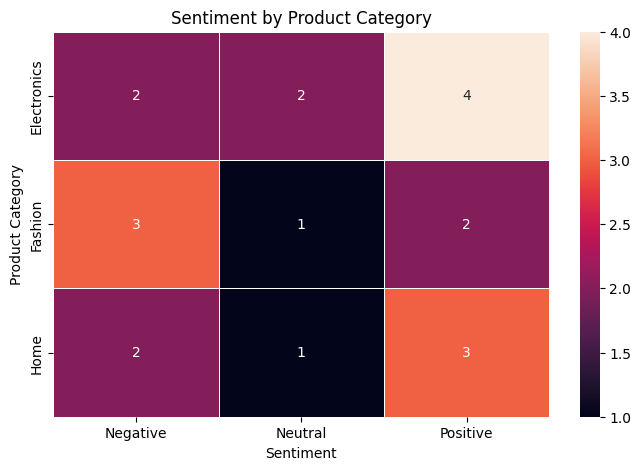

In [ ]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    category_sentiment,
    annot=True,
    fmt="d",
    linewidths=0.5
)

plt.xlabel("Sentiment")
plt.ylabel("Product Category")
plt.title("Sentiment by Product Category")

plt.show()

# Sentiment Summary

The overall sentiment of the reviews is summarized using the number and percentage of each sentiment category.

In [ ]:
total_reviews = len(df)

print("Total Reviews:", total_reviews)

for sentiment, count in sentiment_counts.items():
    percentage = (count / total_reviews) * 100
    print(
        f"{sentiment}: {count} reviews "
        f"({percentage:.2f}%)"
    )

Total Reviews: 20
Positive: 9 reviews (45.00%)
Negative: 7 reviews (35.00%)
Neutral: 4 reviews (20.00%)


# Most Positive and Most Negative Reviews

The reviews with the highest and lowest polarity scores are identified.

In [ ]:
most_positive = df.loc[df["Polarity"].idxmax()]
most_negative = df.loc[df["Polarity"].idxmin()]

print("Most Positive Review:")
print(most_positive["Review"])
print("Polarity:", most_positive["Polarity"])

print("\nMost Negative Review:")
print(most_negative["Review"])
print("Polarity:", most_negative["Polarity"])

Most Positive Review:
The product works perfectly and I recommend it.
Polarity: 1.0

Most Negative Review:
Very disappointing product.
Polarity: -0.78


# Key Findings

The following points summarize the important findings from the sentiment analysis:

- Customer reviews were classified into Positive, Negative, and Neutral categories.
- Sentiment polarity was calculated using TextBlob.
- Positive and negative customer opinions were identified.
- Sentiment patterns were compared across product categories.
- Frequently used words were identified using word-frequency analysis.
- A word cloud was used to visualize common terms.
- A simple emotion lexicon was used to detect specific emotions.
- Sentiment visualization helped understand overall customer opinion.

# Business Insights

Sentiment analysis can support business decisions in several ways:

- Positive reviews can help identify product strengths.
- Negative reviews can highlight product or service problems.
- Neutral reviews can indicate areas where customers have limited emotional response.
- Frequently occurring negative words can help identify recurring complaints.
- Product categories with different sentiment patterns can be investigated further.
- Businesses can use customer sentiment to improve products, services, and marketing strategies.

# Save Sentiment Analysis Dataset

The processed dataset containing sentiment scores, sentiment categories, and detected emotions is saved as a CSV file.

In [ ]:
df.to_csv(
    "CodeAlpha_Task4_Sentiment_Analysis.csv",
    index=False
)

print("Sentiment analysis dataset saved successfully!")

Sentiment analysis dataset saved successfully!


# Save Sentiment Visualization

The main sentiment distribution chart is saved as an image for use in reports and presentations.

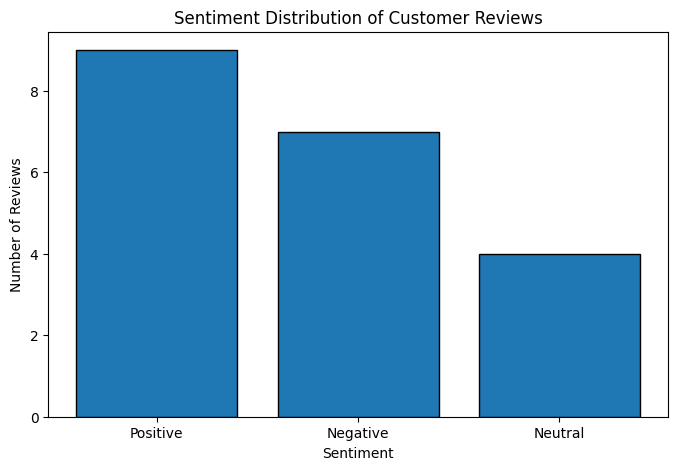

Visualization saved successfully!


In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    edgecolor="black"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution of Customer Reviews")

plt.savefig(
    "CodeAlpha_Task4_Sentiment_Visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Visualization saved successfully!")

# Final Dataset

The final dataset contains the original review, cleaned text, processed text, polarity score, sentiment classification, product category, and detected emotion.

In [ ]:
print("Final Dataset Shape:", df.shape)

df.head(10)

Final Dataset Shape: (20, 8)


,Review_ID,Review,Category,Cleaned_Review,Processed_Review,Polarity,Sentiment,Emotion
0,1,This product is excellent and I really love it.,Electronics,this product is excellent and i really love it,product excellent really love,0.750000,Positive,"Happy, Love, Excited"
1,2,Amazing quality and very useful product.,Electronics,amazing quality and very useful product,amazing quality useful product,0.495000,Positive,"Happy, Excited"
2,3,I am extremely happy with this purchase.,Fashion,i am extremely happy with this purchase,extremely happy purchase,0.800000,Positive,Happy
3,4,The product works perfectly and I recommend it.,Electronics,the product works perfectly and i recommend it,product works perfectly recommend,1.000000,Positive,Neutral
4,5,Fantastic product with great quality.,Home,fantastic product with great quality,fantastic product great quality,0.600000,Positive,"Happy, Love, Excited"
5,6,Very good product and worth the money.,Fashion,very good product and worth the money,good product worth money,0.605000,Positive,Happy
6,7,I am satisfied with the product.,Home,i am satisfied with the product,satisfied product,0.500000,Positive,Happy
7,8,The product is okay and works as expected.,Electronics,the product is okay and works as expected,product okay works expected,0.200000,Positive,Neutral
8,9,It is an average product for the price.,Fashion,it is an average product for the price,average product price,-0.150000,Negative,Neutral
9,10,The product is normal and nothing special.,Home,the product is normal and nothing special,product normal nothing special,0.253571,Positive,Neutral


# Conclusion

Sentiment Analysis was successfully performed on customer review data using Natural Language Processing techniques.

Text preprocessing was performed to clean the reviews. TextBlob was used to calculate sentiment polarity and classify reviews as Positive, Negative, or Neutral. A simple emotion lexicon was also used to identify specific emotions.

Different visualizations were created to understand sentiment distribution, product-category sentiment, polarity, word frequency, and emotions.

The analysis demonstrates how sentiment patterns can help organizations understand customer opinions and support product improvement, marketing decisions, and customer experience analysis.